<a href="https://colab.research.google.com/github/young0206/computer_vision/blob/main/06.%EC%9E%84%EB%B2%A0%EB%94%94%EB%93%9C/04.CharNet/Charnet_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Mounting Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
cd /content/drive/MyDrive/33project/06.임베디드/04.CharNet/charnet_pytorch

/content/drive/MyDrive/33project/06.임베디드/04.CharNet/charnet_pytorch


#Installing Dependencies

In [3]:
!pip install pyclipper
!pip install yacs
!pip install --upgrade --no-cache-dir gdown
!python setup.py build develop

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 972.1/972.1 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.8/50.8 kB 19.0 MB/s eta 0:00:00
  Attempting uninstall: gdown
    Found existing installation: gdown 5.2.2
    Uninstalling gdown-5.2.2:
      Successfully uninstalled gdown-5.2.2
running build
running build_py
creating build/lib/charnet
copying charnet/__init__.py -> build/lib/charnet
creating build/lib/charnet/config
copying charnet/config/defaults.py -> build/lib/charnet/config
copying charnet/config/__init__.py -> build/lib/charnet/config
creating build/lib/charnet/modeling
copying charnet/modeling/__init__.py -> build/lib/charnet/modeling
copying charnet/modeling/model.py -> build/lib/charnet/modeling
copying charnet/modeling/rotated_nms.py -> build/lib/charnet/modeling
copying charnet/modeling/utils.py -> build/lib/charnet/modeling
copying charnet/modeling/postprocessing.py -> build/lib/charnet/modeling
creating build/lib/charnet/modeling/layers
copying 

#Importing Libraries

In [4]:
import torch
import cv2, os
import numpy as np
from charnet.config import cfg
import matplotlib.pyplot as plt
from torch import nn
from charnet.modeling.backbone.resnet import resnet50
from charnet.modeling.backbone.hourglass import hourglass88
from charnet.modeling.backbone.decoder import Decoder
from collections import OrderedDict
from torch.functional import F
from charnet.modeling.layers import Scale
import torchvision.transforms as T
from charnet.modeling.postprocessing import OrientedTextPostProcessing

#Defining Variables

In [5]:
dataset='icdar_2015'
image_dir='icdar_2015'
results_dir='results'
config_file='configs/icdar2015_hourglass88.yaml'
weights='weights'

#Downloading PreTrained Weights

In [6]:
if os.path.exists(weights) is False:
  print("Downloading PreTrained Weights")
  !bash download_weights.sh
else:
  print('Weights Already Downloaded')

bash: download_weights.sh: No such file or directory


#Downloading Dataset

In [7]:
import os
if os.path.exists(dataset) is False:
  print("Downloading Dataset")
  !mkdir icdar_2015
  !mkdir results
  !gdown https://drive.google.com/u/0/uc?id=1mPRmedDdC9UPlNQAEohMCMWlnTRoiqfC&export=download
  !unzip ch4_test_images.zip -d icdar_2015
else:
  print('Dataset already Downloaded')


Downloading...
From (original): https://drive.google.com/uc?id=1mPRmedDdC9UPlNQAEohMCMWlnTRoiqfC
From (redirected): https://drive.google.com/uc?id=1mPRmedDdC9UPlNQAEohMCMWlnTRoiqfC&confirm=t&uuid=91415f98-ef2f-40f6-9d9f-ad65737bc3dc
To: /content/drive/MyDrive/33project/06.임베디드/04.CharNet/charnet_pytorch/ch4_test_images.zip
100% 44.4M/44.4M [00:00<00:00, 47.6MB/s]
Archive:  ch4_test_images.zip
  inflating: icdar_2015/img_1.jpg    
  inflating: icdar_2015/img_2.jpg    
  inflating: icdar_2015/img_3.jpg    
  inflating: icdar_2015/img_4.jpg    
  inflating: icdar_2015/img_5.jpg    
  inflating: icdar_2015/img_6.jpg    
  inflating: icdar_2015/img_7.jpg    
  inflating: icdar_2015/img_8.jpg    
  inflating: icdar_2015/img_9.jpg    
  inflating: icdar_2015/img_10.jpg   
  inflating: icdar_2015/img_11.jpg   
  inflating: icdar_2015/img_12.jpg   
  inflating: icdar_2015/img_13.jpg   
  inflating: icdar_2015/img_14.jpg   
  inflating: icdar_2015/img_15.jpg   
  inflating: icdar_2015/img_1

#Defining Model

In [8]:
def _conv3x3_bn_relu(in_channels, out_channels, dilation=1):
    return nn.Sequential(OrderedDict([
        ("conv", nn.Conv2d(
            in_channels, out_channels, kernel_size=3, stride=1,
            padding=dilation, dilation=dilation, bias=False
        )),
        ("bn", nn.BatchNorm2d(out_channels)),
        ("relu", nn.ReLU())
    ]))


def to_numpy_or_none(*tensors):
    results = []
    for t in tensors:
        if t is None:
            results.append(None)
        else:
            results.append(t.cpu().numpy())
    return results


class WordDetector(nn.Module):
    def __init__(self, in_channels, bottleneck_channels, dilation=1):
        super(WordDetector, self).__init__()
        self.word_det_conv_final = _conv3x3_bn_relu(
            in_channels, bottleneck_channels, dilation
        )
        self.word_fg_feat = _conv3x3_bn_relu(
            bottleneck_channels, bottleneck_channels, dilation
        )
        self.word_regression_feat = _conv3x3_bn_relu(
            bottleneck_channels, bottleneck_channels, dilation
        )
        self.word_fg_pred = nn.Conv2d(bottleneck_channels, 2, kernel_size=1)
        self.word_tblr_pred = nn.Conv2d(bottleneck_channels, 4, kernel_size=1)
        self.orient_pred = nn.Conv2d(bottleneck_channels, 1, kernel_size=1)

    def forward(self, x):
        feat = self.word_det_conv_final(x)

        pred_word_fg = self.word_fg_pred(self.word_fg_feat(feat))

        word_regression_feat = self.word_regression_feat(feat)
        pred_word_tblr = F.relu(self.word_tblr_pred(word_regression_feat)) * 10.
        pred_word_orient = self.orient_pred(word_regression_feat)

        return pred_word_fg, pred_word_tblr, pred_word_orient


class CharDetector(nn.Module):
    def __init__(self, in_channels, bottleneck_channels, curved_text_on=False):
        super(CharDetector, self).__init__()
        self.character_det_conv_final = _conv3x3_bn_relu(
            in_channels, bottleneck_channels
        )
        self.char_fg_feat = _conv3x3_bn_relu(
            bottleneck_channels, bottleneck_channels
        )
        self.char_regression_feat = _conv3x3_bn_relu(
            bottleneck_channels, bottleneck_channels
        )
        self.char_fg_pred = nn.Conv2d(bottleneck_channels, 2, kernel_size=1)
        self.char_tblr_pred = nn.Conv2d(bottleneck_channels, 4, kernel_size=1)

    def forward(self, x):
        feat = self.character_det_conv_final(x)

        pred_char_fg = self.char_fg_pred(self.char_fg_feat(feat))
        char_regression_feat = self.char_regression_feat(feat)
        pred_char_tblr = F.relu(self.char_tblr_pred(char_regression_feat)) * 10.
        pred_char_orient = None

        return pred_char_fg, pred_char_tblr, pred_char_orient


class CharRecognizer(nn.Module):
    def __init__(self, in_channels, bottleneck_channels, num_classes):
        super(CharRecognizer, self).__init__()

        self.body = nn.Sequential(
            _conv3x3_bn_relu(in_channels, bottleneck_channels),
            _conv3x3_bn_relu(bottleneck_channels, bottleneck_channels),
            _conv3x3_bn_relu(bottleneck_channels, bottleneck_channels),
        )
        self.classifier = nn.Conv2d(bottleneck_channels, num_classes, kernel_size=1)

    def forward(self, feat):
        feat = self.body(feat)
        return self.classifier(feat)


class CharNet(nn.Module):
    def __init__(self, backbone=hourglass88()):
        super(CharNet, self).__init__()
        self.backbone = backbone
        decoder_channels = 256
        bottleneck_channels = 128
        self.word_detector = WordDetector(
            decoder_channels, bottleneck_channels,
            dilation=cfg.WORD_DETECTOR_DILATION
        )
        self.char_detector = CharDetector(
            decoder_channels,
            bottleneck_channels
        )
        self.char_recognizer = CharRecognizer(
            decoder_channels, bottleneck_channels,
            num_classes=cfg.NUM_CHAR_CLASSES
        )

        args = {
            "word_min_score": cfg.WORD_MIN_SCORE,
            "word_stride": cfg.WORD_STRIDE,
            "word_nms_iou_thresh": cfg.WORD_NMS_IOU_THRESH,
            "char_stride": cfg.CHAR_STRIDE,
            "char_min_score": cfg.CHAR_MIN_SCORE,
            "num_char_class": cfg.NUM_CHAR_CLASSES,
            "char_nms_iou_thresh": cfg.CHAR_NMS_IOU_THRESH,
            "char_dict_file": cfg.CHAR_DICT_FILE,
            "word_lexicon_path": cfg.WORD_LEXICON_PATH
        }

        self.post_processing = OrientedTextPostProcessing(**args)

        self.transform = self.build_transform()

    def forward(self, im, im_scale_w, im_scale_h, original_im_w, original_im_h):
        im = self.transform(im).cuda()
        im = im.unsqueeze(0)
        features = self.backbone(im)

        pred_word_fg, pred_word_tblr, pred_word_orient = self.word_detector(features)
        pred_char_fg, pred_char_tblr, pred_char_orient = self.char_detector(features)
        recognition_results = self.char_recognizer(features)

        pred_word_fg = F.softmax(pred_word_fg, dim=1)
        pred_char_fg = F.softmax(pred_char_fg, dim=1)
        pred_char_cls = F.softmax(recognition_results, dim=1)

        pred_word_fg, pred_word_tblr, \
        pred_word_orient, pred_char_fg, \
        pred_char_tblr, pred_char_cls, \
        pred_char_orient = to_numpy_or_none(
            pred_word_fg, pred_word_tblr,
            pred_word_orient, pred_char_fg,
            pred_char_tblr, pred_char_cls,
            pred_char_orient
        )

        char_bboxes, char_scores, word_instances = self.post_processing(
            pred_word_fg[0, 1], pred_word_tblr[0],
            pred_word_orient[0, 0], pred_char_fg[0, 1],
            pred_char_tblr[0], pred_char_cls[0],
            im_scale_w, im_scale_h,
            original_im_w, original_im_h
        )

        return char_bboxes, char_scores, word_instances

    def build_transform(self):
        to_rgb_transform = T.Lambda(lambda x: x[[2, 1, 0]])

        normalize_transform = T.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )

        transform = T.Compose(
            [
                T.ToPILImage(),
                T.ToTensor(),
                to_rgb_transform,
                normalize_transform,
            ]
        )
        return transform


#Inference

In [10]:
import os

print("현재 경로:", os.getcwd())

print("\n=== weights 폴더 ===")
!find . -type d -name "weights"

print("\n=== CharNet 가중치 파일 ===")
!find . -type f \( -name "*.pth" -o -name "*.pt" \)

현재 경로: /content/drive/MyDrive/33project/06.임베디드/04.CharNet/charnet_pytorch

=== weights 폴더 ===

=== CharNet 가중치 파일 ===


In [13]:
!pip -q install -U huggingface_hub

from huggingface_hub import hf_hub_download
import os, shutil

os.makedirs("weights", exist_ok=True)

downloaded = hf_hub_download(
    repo_id="shikunl/prismer",
    filename="expert_weights/icdar2015_hourglass88.pth"
)

target = "weights/icdar2015_hourglass88.pth"
shutil.copyfile(downloaded, target)

print("다운로드 완료:", target)
print("파일 크기:", os.path.getsize(target), "bytes")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.0/838.0 kB 22.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.8.5 requires huggingface-hub<2.0,>=0.25.0, but you have huggingface-hub 2.1.1 which is incompatible.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 2.1.1 which is incompatible.
tokenizers 0.23.2 requires huggingface-hub<2.0,>=0.16.4, but you have huggingface-hub 2.1.1 which is incompatible.
gradio-client 2.7.1 requires huggingface-hub<2.0,>=0.19.3, but you have huggingface-hub 2.1.1 which is incompatible.


expert_weights/icdar2015_hourglass88.pth: reconstructing file:   0%|          |  0.00B /  357MB            

expert_weights/icdar2015_hourglass88.pth: downloading bytes:           |  0.00B            

다운로드 완료: weights/icdar2015_hourglass88.pth
파일 크기: 356919946 bytes


CHAR_DICT_FILE: datasets/ICDAR2015/test/char_dict.txt
CHAR_MIN_SCORE: 0.25
CHAR_NMS_IOU_THRESH: 0.3
CHAR_STRIDE: 4
INPUT_SIZE: 2280
MAGNITUDE_THRESH: 0.2
NUM_CHAR_CLASSES: 68
RESULTS_SEPARATOR: ,
SIZE_DIVISIBILITY: 128
WEIGHT: weights/icdar2015_hourglass88.pth
WORD_DETECTOR_DILATION: 1
WORD_LEXICON_PATH: datasets/ICDAR2015/test/GenericVocabulary.txt
WORD_MIN_SCORE: 0.95
WORD_NMS_IOU_THRESH: 0.15
WORD_STRIDE: 4
Processing img_1.jpg...


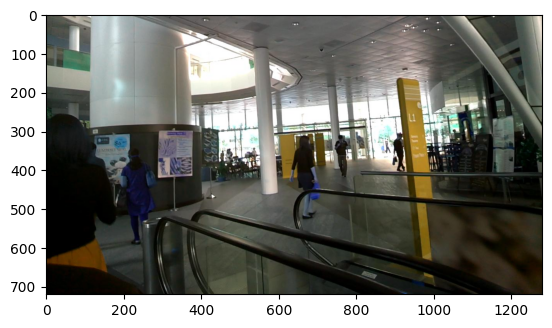

Processing img_2.jpg...


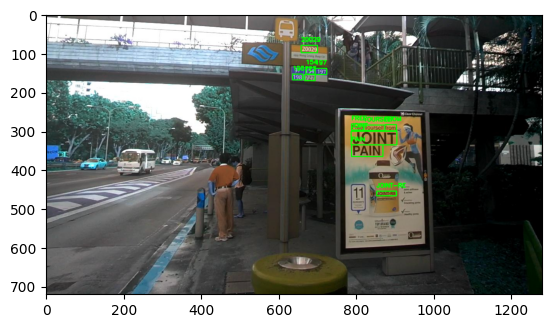

Processing img_3.jpg...


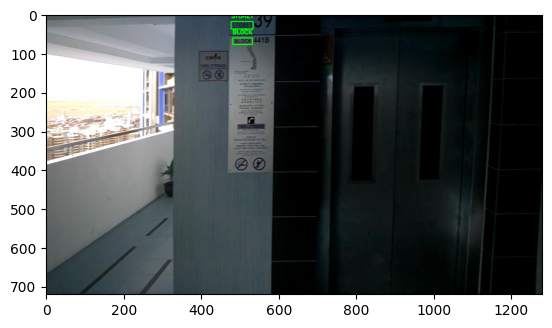

Processing img_4.jpg...


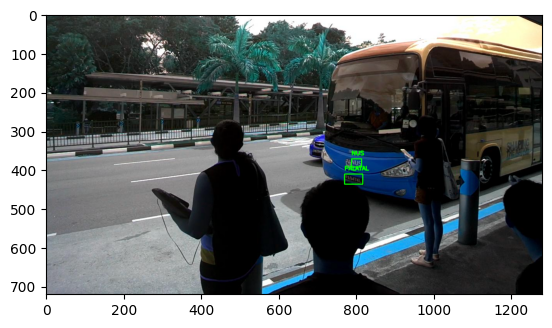

Processing img_5.jpg...


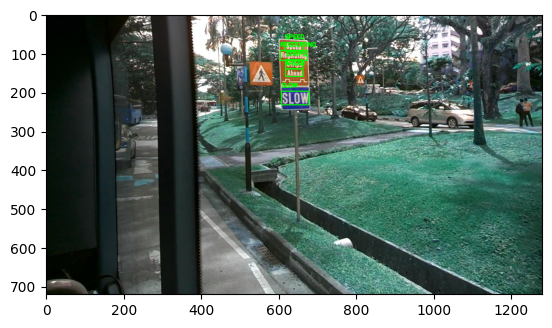

In [14]:
def save_word_recognition(word_instances, image_id, save_root, separator=chr(31)):
    with open('{}/{}.txt'.format(save_root, image_id), 'wt') as fw:
        for word_ins in word_instances:
            if len(word_ins.text) > 0:
                fw.write(separator.join([str(_) for _ in word_ins.word_bbox.astype(np.int32).flat]))
                fw.write(separator)
                fw.write(word_ins.text)
                fw.write('\n')
    for word_ins in word_instances:
      if len(word_ins.text) > 0:
          bbox = word_ins.word_bbox.astype(np.int32)
          cv2.rectangle(im_original, (bbox[0], bbox[1]), (bbox[4], bbox[5]), (0, 255, 0), 2)
          cv2.putText(im_original, word_ins.text, (bbox[0], bbox[1]-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    cv2.imwrite('{}/{}.jpg'.format(results_dir, os.path.splitext(im_name)[0]), im_original)
    plt.imshow(im_original)
    plt.show()

def resize(im, size):
    h, w, _ = im.shape
    scale = max(h, w) / float(size)
    image_resize_height = int(round(h / scale / cfg.SIZE_DIVISIBILITY) * cfg.SIZE_DIVISIBILITY)
    image_resize_width = int(round(w / scale / cfg.SIZE_DIVISIBILITY) * cfg.SIZE_DIVISIBILITY)
    scale_h = float(h) / image_resize_height
    scale_w = float(w) / image_resize_width
    im = cv2.resize(im, (image_resize_width, image_resize_height), interpolation=cv2.INTER_LINEAR)
    return im, scale_w, scale_h, w, h


cfg.merge_from_file(config_file)
cfg.freeze()

print(cfg)

charnet = CharNet()
charnet.load_state_dict(torch.load(cfg.WEIGHT))
charnet.eval()
charnet.cuda()

for im_name in sorted(os.listdir(image_dir)[:5]):
    print("Processing {}...".format(im_name))
    im_file = os.path.join(image_dir, im_name)
    im_original = cv2.imread(im_file)
    im, scale_w, scale_h, original_w, original_h = resize(im_original, size=cfg.INPUT_SIZE)
    with torch.no_grad():
        char_bboxes, char_scores, word_instances = charnet(im, scale_w, scale_h, original_w, original_h)
        save_word_recognition(
            word_instances, os.path.splitext(im_name)[0],
            results_dir, cfg.RESULTS_SEPARATOR
        )
